In [1]:
import os
import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss,
    accuracy_score,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import shap
from scipy.stats import kendalltau
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, selection_rate, MetricFrame

from dotenv import load_dotenv

warnings.filterwarnings("ignore")
SEED = 42

def set_all_seeds(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds()

from lime.lime_tabular import LimeTabularExplainer

try:
    from langchain_google_genai import ChatGoogleGenerativeAI
    from langchain_core.prompts import ChatPromptTemplate
    GEMINI_READY = True
except Exception:
    GEMINI_READY = False

print("Environment ready. Torch:", torch.__version__)
print("Gemini libs available:", GEMINI_READY)

Environment ready. Torch: 2.10.0+cpu
Gemini libs available: True


## Data Loading and Preprocessing

In [2]:
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent
data_dir = project_root / "data"

df1_raw = pd.read_excel(data_dir / "case_study1.xlsx")
df2_raw = pd.read_excel(data_dir / "case_study2.xlsx")

print("Raw df1 shape:", df1_raw.shape)
print("Raw df2 shape:", df2_raw.shape)

Raw df1 shape: (51336, 26)
Raw df2 shape: (51336, 62)


In [3]:
SENTINEL = -99_999
TARGET = "Approved_Flag"
ANCHOR = "Age_Oldest_TL"
LEAKAGE_COLS = ["PROSPECTID", "Credit_Score"]

In [4]:
def preprocess_with_null_cap(null_cap: int) -> pd.DataFrame:
    df1 = df1_raw.copy()
    df2 = df2_raw.copy()

    df1.replace(SENTINEL, np.nan, inplace=True)
    df2.replace(SENTINEL, np.nan, inplace=True)

    df1.dropna(subset=[ANCHOR], inplace=True)

    min_valid = len(df2) - null_cap
    df2.dropna(axis=1, thresh=min_valid, inplace=True)
    df2.dropna(inplace=True)

    merged = pd.merge(df1, df2, how="inner", on="PROSPECTID")
    return merged

In [5]:
target_test_size = 8524
candidate_caps = list(range(6000, 18001, 500))
best = None

for cap in candidate_caps:
    try:
        tmp = preprocess_with_null_cap(cap)
        approx_test = int(round(len(tmp) * 0.20))
        gap = abs(approx_test - target_test_size)
        cand = {"cap": cap, "rows": len(tmp), "test_rows": approx_test, "gap": gap}
        if best is None or cand["gap"] < best["gap"]:
            best = cand
    except Exception:
        continue

if best is None:
    raise RuntimeError("No valid preprocessing candidate found.")

NULL_CAP = best["cap"]
df = preprocess_with_null_cap(NULL_CAP)

print(f"Selected NULL_CAP={NULL_CAP}, merged rows={len(df):,}, expected test rows~{best['test_rows']:,}")

Selected NULL_CAP=6500, merged rows=42,064, expected test rows~8,413


In [6]:
# Keep raw data copy for fairness grouping.
df_raw = df.copy()

df_model = df.drop(columns=LEAKAGE_COLS, errors="ignore").copy()
categorical_cols = [c for c in df_model.select_dtypes(include="object").columns if c != TARGET]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True, dtype=int)
X = df_encoded.drop(columns=[TARGET]).astype(float)
y_raw = df_encoded[TARGET]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
classes = label_encoder.classes_
n_classes = len(classes)

print("Encoded shape:", X.shape)
print("Classes:", classes)

Encoded shape: (42064, 89)
Classes: ['P1' 'P2' 'P3' 'P4']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

X_train_tree = X_train.copy()
X_test_tree = X_test.copy()
df_test_raw = df_raw.loc[X_test.index].copy()

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Aligned fairness frame rows:", len(df_test_raw))

Train: (33651, 89) Test: (8413, 89)
Aligned fairness frame rows: 8413


## Leakage-Safe 5-Fold CV

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=SEED)),
    ("scaler", StandardScaler()),
    ("clf", xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1,
    )),
])

cv_scoring = {
    "f1_weighted": "f1_weighted",
    "f1_macro": "f1_macro",
    "roc_auc_ovr_weighted": "roc_auc_ovr_weighted",
}

cv_results = cross_validate(cv_pipeline, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1)

print("CV Weighted F1:", round(float(cv_results['test_f1_weighted'].mean()), 4))
print("CV Macro F1:", round(float(cv_results['test_f1_macro'].mean()), 4))
print("CV ROC-AUC OVR weighted:", round(float(cv_results['test_roc_auc_ovr_weighted'].mean()), 4))

CV Weighted F1: 0.7682
CV Macro F1: 0.6942
CV ROC-AUC OVR weighted: 0.9183


## Train Ensemble (Paper Architecture) and Baselines

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=-1,
)

In [10]:
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    max_depth=6,
    n_estimators=260,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    random_state=SEED,
    n_jobs=-1,
)

In [11]:
hist_model = HistGradientBoostingClassifier(
    max_iter=220,
    max_depth=6,
    learning_rate=0.06,
    random_state=SEED,
)

In [12]:
meta_learner = LogisticRegression(max_iter=1500, class_weight="balanced", random_state=SEED)

In [13]:
ensemble = StackingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model), ("hist", hist_model)],
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
)

ensemble.fit(X_train_tree, y_train)

# Calibrate and materialize ensemble probabilities for downstream hybrid blend.
calibrated_ensemble = CalibratedClassifierCV(
    estimator=ensemble,
    method="sigmoid",
    cv=3,
    n_jobs=-1,
)
calibrated_ensemble.fit(X_train_tree, y_train)
ensemble_probs = calibrated_ensemble.predict_proba(X_test_tree)

In [14]:
# Baselines required
lr_baseline = SkPipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
])


lr_baseline.fit(X_train, y_train)
lr_probs = lr_baseline.predict_proba(X_test)

In [15]:
svm_baseline = SkPipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED)),
])
svm_baseline.fit(X_train, y_train)
svm_probs = svm_baseline.predict_proba(X_test)

print("Ensemble prob shape:", ensemble_probs.shape)
print("SVM prob shape:", svm_probs.shape)

Ensemble prob shape: (8413, 4)
SVM prob shape: (8413, 4)


## Train Neural Network Branch

In [16]:
smote = SMOTE(random_state=SEED)
X_train_nn, y_train_nn = smote.fit_resample(X_train, y_train)

In [17]:
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train_nn)
X_test_scaled = scaler_nn.transform(X_test)

In [18]:
class CreditScoringNN(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [19]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_nn),
    y=y_train_nn,
).astype(float)

In [20]:
#  P3 multiplier is 1.55.
if "P3" in classes:
    p3_idx = int(np.where(classes == "P3")[0][0])
    class_weights[p3_idx] *= 1.55

In [21]:
nn_model = CreditScoringNN(input_dim=X_train_scaled.shape[1], num_classes=n_classes)
criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights), label_smoothing=0.03)
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

In [22]:
X_tr_t = torch.FloatTensor(X_train_scaled)
y_tr_t = torch.LongTensor(y_train_nn)
X_te_t = torch.FloatTensor(X_test_scaled)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

In [23]:
EPOCHS = 24
history = []
for epoch in range(1, EPOCHS + 1):
    nn_model.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item()
    scheduler.step()
    history.append(running / len(train_loader))
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d}/{EPOCHS} - loss={history[-1]:.4f}")


Epoch 05/24 - loss=0.6289
Epoch 10/24 - loss=0.5899
Epoch 15/24 - loss=0.5718
Epoch 20/24 - loss=0.5607


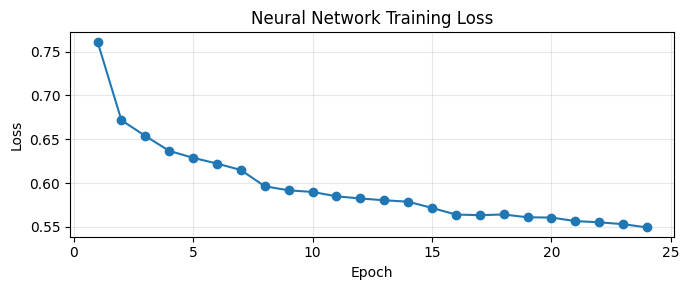

NN probability shape: (8413, 4)


In [24]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, EPOCHS + 1), history, marker="o")
plt.title("Neural Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

nn_model.eval()
with torch.no_grad():
    nn_probs = torch.softmax(nn_model(X_te_t), dim=1).numpy()

print("NN probability shape:", nn_probs.shape)

## Hybrid Soft Vote Search and Metrics

In [25]:
COMBOS = [
    (1.00, 0.00),
    (0.90, 0.10),
    (0.80, 0.20),
    (0.70, 0.30),
    (0.60, 0.40)
]

blend_records = []
for w_ens, w_nn in COMBOS:
    probs = (w_ens * ensemble_probs) + (w_nn * nn_probs)
    pred = np.argmax(probs, axis=1)

    rec = {
        "w_ens": float(w_ens),
        "w_nn": float(w_nn),
        "Accuracy": accuracy_score(y_test, pred),
        "Weighted F1": f1_score(y_test, pred, average="weighted"),
        "Macro F1": f1_score(y_test, pred, average="macro"),
        "ROC-AUC (OVR,w)": roc_auc_score(y_test, probs, multi_class="ovr", average="weighted"),
        "Log Loss": log_loss(y_test, probs),
    }
    blend_records.append(rec)

In [26]:
blend_search_df = pd.DataFrame(blend_records)
blend_search_df = blend_search_df.sort_values(
    ["Weighted F1", "ROC-AUC (OVR,w)", "Accuracy"],
    ascending=False,
).reset_index(drop=True)


W_ENS = float(blend_search_df.loc[0, "w_ens"])
W_NN = float(blend_search_df.loc[0, "w_nn"])

hybrid_probs = (W_ENS * ensemble_probs) + (W_NN * nn_probs)
y_pred_hybrid = np.argmax(hybrid_probs, axis=1)

blend_view = blend_search_df.copy()
blend_view["Blend"] = blend_view.apply(lambda r: f"{int(r['w_ens']*100)}/{int(r['w_nn']*100)}", axis=1)
ordered_cols = ["Blend", "Accuracy", "Weighted F1", "Macro F1", "ROC-AUC (OVR,w)", "Log Loss"]
for col in ordered_cols[1:]:
    blend_view[col] = blend_view[col].map(lambda x: round(float(x), 4))

In [27]:
print("Blend comparison results (sorted best-first):")
display(blend_view[ordered_cols])
print(f"Selected blend: Ensemble {W_ENS:.0%}, NN {W_NN:.0%}")

Blend comparison results (sorted best-first):


,Blend,Accuracy,Weighted F1,Macro F1,"ROC-AUC (OVR,w)",Log Loss
0,60/40,0.7801,0.7755,0.7081,0.9197,0.5130
1,70/30,0.7819,0.7709,0.6987,0.9202,0.5095
2,80/20,0.7833,0.7665,0.6912,0.9201,0.5091
3,90/10,0.7840,0.7617,0.6829,0.9190,0.5122
4,100/0,0.7838,0.7565,0.6741,0.9167,0.5204


Selected blend: Ensemble 60%, NN 40%


In [28]:
def multiclass_brier(y_true_idx: np.ndarray, probs: np.ndarray, n_cls: int) -> float:
    y_ohe = np.eye(n_cls)[y_true_idx]
    return float(np.mean(np.sum((probs - y_ohe) ** 2, axis=1)))


In [29]:
def multiclass_ece(y_true_idx: np.ndarray, probs: np.ndarray, n_bins: int = 10) -> float:
    # [Paper change] ECE with 10 equal-width bins.
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    corr = (pred == y_true_idx).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n = len(y_true_idx)

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        if i < n_bins - 1:
            mask = (conf >= left) & (conf < right)
        else:
            mask = (conf >= left) & (conf <= right)

        if not np.any(mask):
            continue

        bin_acc = float(corr[mask].mean())
        bin_conf = float(conf[mask].mean())
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)
        
    return float(ece)


In [30]:
def evaluate_probs(model_name: str, y_true: np.ndarray, probs: np.ndarray) -> dict:
    y_pred = np.argmax(probs, axis=1)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "ROC-AUC (OVR,w)": roc_auc_score(y_true, probs, multi_class="ovr", average="weighted"),
        "Brier": multiclass_brier(y_true, probs, n_classes),
        "Log Loss": log_loss(y_true, probs),
        "ECE (10 bins)": multiclass_ece(y_true, probs, n_bins=10),
    }

In [31]:
rows = [
    evaluate_probs("Baseline: Logistic Regression", y_test, lr_probs),
    evaluate_probs("Baseline: SVM (RBF)", y_test, svm_probs),
    evaluate_probs("Stacking Ensemble (RF+XGB+HistGB)", y_test, ensemble_probs),
    evaluate_probs("Neural Network", y_test, nn_probs),
    evaluate_probs(f"Hybrid (best blend {int(W_ENS*100)}/{int(W_NN*100)})", y_test, hybrid_probs),
]

In [32]:
ablation_results = pd.DataFrame(rows)
num_cols = [c for c in ablation_results.columns if c != "Model"]
ablation_results[num_cols] = ablation_results[num_cols].applymap(lambda v: round(float(v), 4))

print("Ablation and Baselines")
display(ablation_results)

Ablation and Baselines


,Model,Accuracy,Weighted F1,Macro F1,"ROC-AUC (OVR,w)",Brier,Log Loss,ECE (10 bins)
0,Baseline: Logistic Regression,0.6856,0.7019,0.6494,0.8738,0.4433,0.7831,0.0827
1,Baseline: SVM (RBF),0.7548,0.7380,0.6537,0.8963,0.3280,0.5770,0.0259
2,Stacking Ensemble (RF+XGB+HistGB),0.7838,0.7565,0.6741,0.9167,0.2997,0.5204,0.0352
3,Neural Network,0.7219,0.7429,0.6970,0.9089,0.3613,0.6079,0.0678
4,Hybrid (best blend 60/40),0.7801,0.7755,0.7081,0.9197,0.2947,0.5130,0.0486


In [33]:
print("Hybrid classification report")
print(classification_report(y_test, y_pred_hybrid, target_names=classes))

print("Blend selected from combination search; metrics reflect the chosen blend.")

Hybrid classification report
              precision    recall  f1-score   support

          P1       0.81      0.81      0.81       982
          P2       0.84      0.89      0.87      5090
          P3       0.43      0.39      0.41      1288
          P4       0.81      0.70      0.75      1053

    accuracy                           0.78      8413
   macro avg       0.72      0.70      0.71      8413
weighted avg       0.77      0.78      0.78      8413

Blend selected from combination search; metrics reflect the chosen blend.


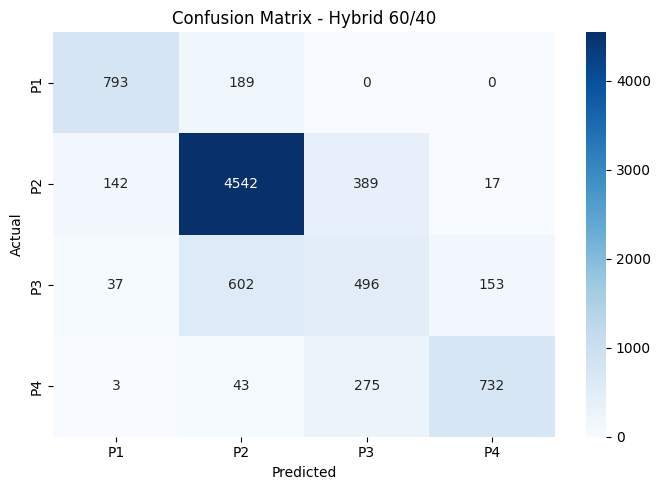

In [34]:
cm = confusion_matrix(y_test, y_pred_hybrid)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title(f"Confusion Matrix - Hybrid {int(W_ENS*100)}/{int(W_NN*100)}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## SHAP and LIME with Kendall Tau

Global SHAP bar (top 15)


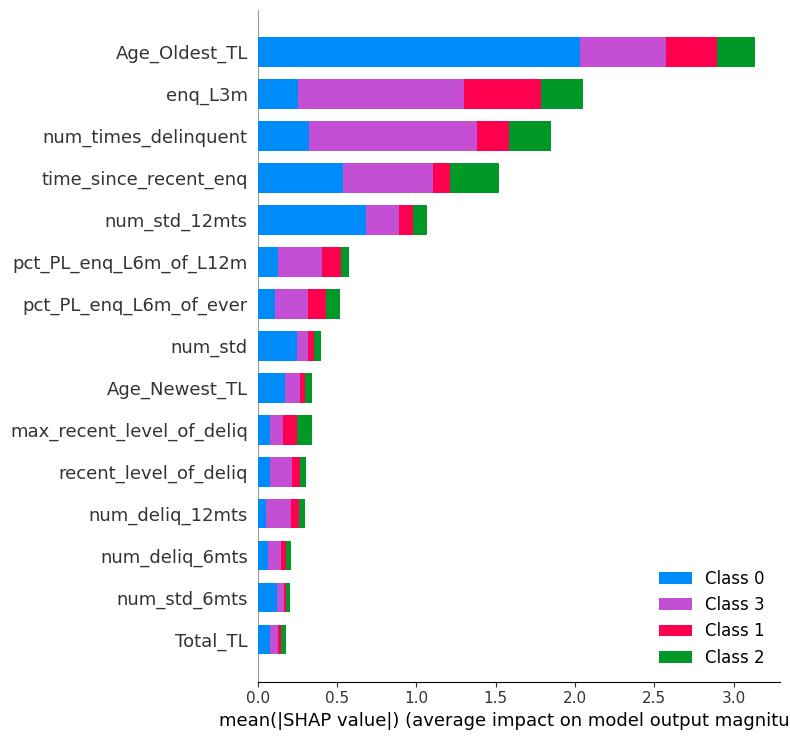

In [35]:
fitted_xgb = ensemble.named_estimators_["xgb"]

SHAP_N = min(500, len(X_test_tree))
X_explain = X_test_tree.sample(n=SHAP_N, random_state=SEED)

shap.initjs()
shap_explainer = shap.TreeExplainer(fitted_xgb)
shap_values = shap_explainer.shap_values(X_explain)

print("Global SHAP bar (top 15)")
shap.summary_plot(shap_values, X_explain, plot_type="bar", max_display=15)

In [36]:
# Prepare a consistent SHAP tensor for per-class beeswarm plots.
if isinstance(shap_values, list):
    # list of [n_samples, n_features] per class
    sv_stack = np.stack(shap_values, axis=2)  # [n, f, c]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Could be [n, f, c] or [c, n, f]
    if shap_values.shape[0] == len(X_explain):
        sv_stack = shap_values
    else:
        sv_stack = np.transpose(shap_values, (1, 2, 0))
else:
    # Binary/single-output fallback
    sv_stack = np.expand_dims(np.asarray(shap_values), axis=2)

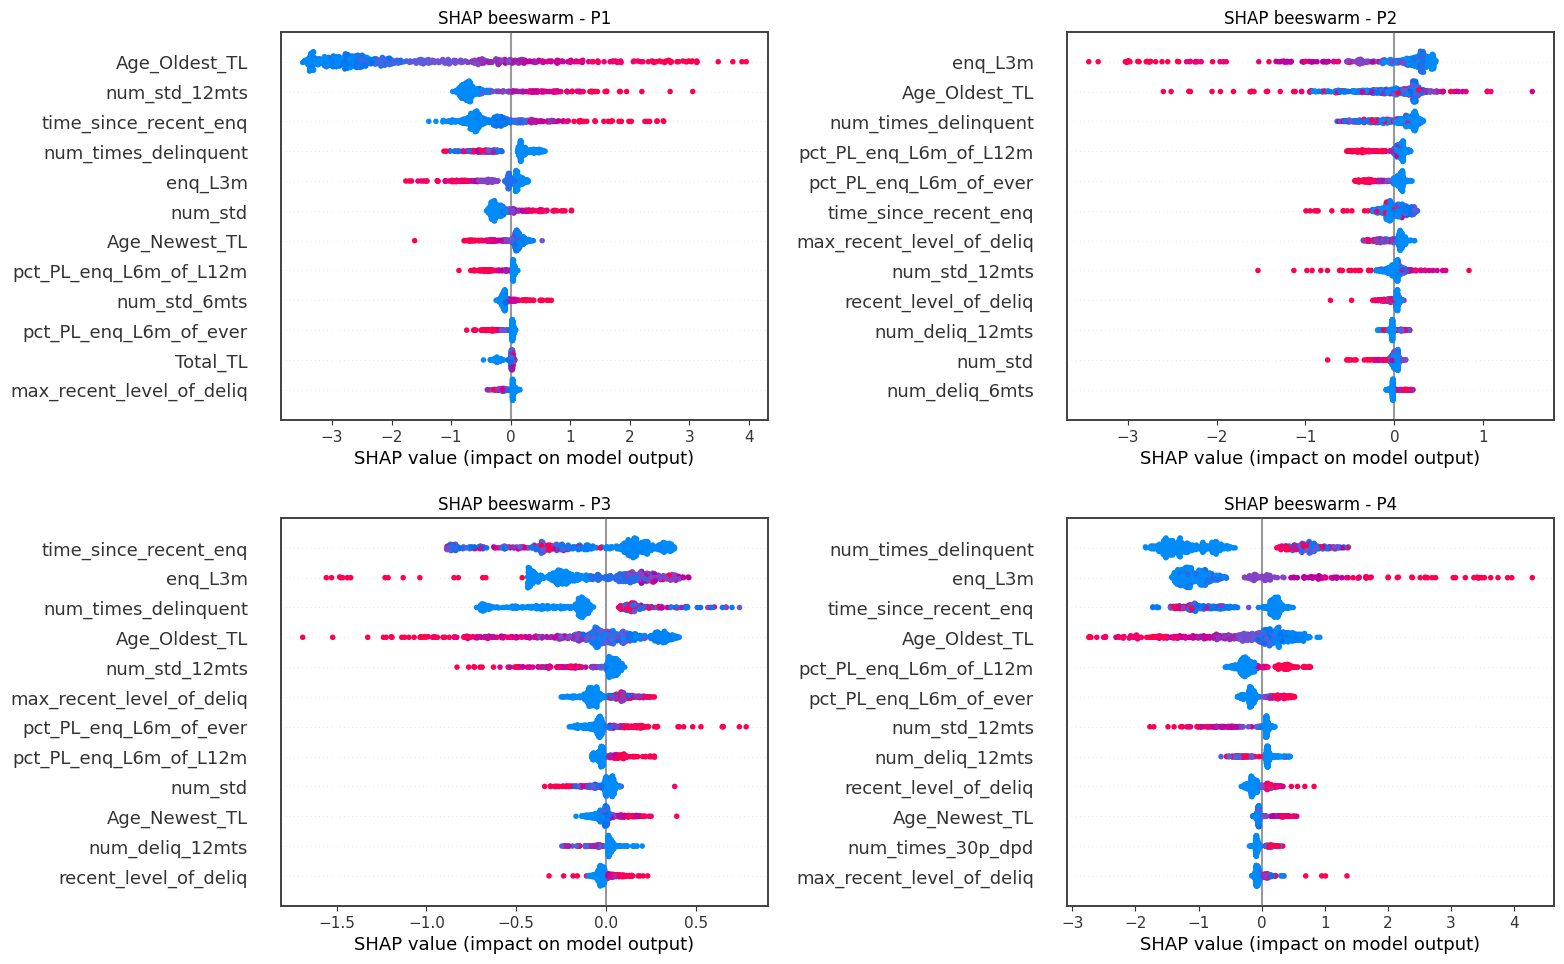

In [53]:
import math

n_show_classes = min(len(classes), sv_stack.shape[2])
n_cols = 2
n_rows = math.ceil(n_show_classes / n_cols)

plt.figure(figsize=(16, 5 * n_rows))

for idx in range(n_show_classes):
    cls_name = classes[idx] if idx < len(classes) else f"Class {idx}"
    ax = plt.subplot(n_rows, n_cols, idx + 1)

    shap.summary_plot(
        sv_stack[:, :, idx],
        X_explain,
        max_display=12,
        show=False,
        plot_size=None,
        color_bar=False,
    )

    ax.set_title(f"SHAP beeswarm - {cls_name}")

    # Draw a clean visible border around each subplot.
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("#404040")
    ax.patch.set_facecolor("white")
    ax.patch.set_edgecolor("#404040")
    ax.patch.set_linewidth(1.2)

plt.tight_layout(pad=2.0, w_pad=2.0, h_pad=2.0)
plt.show()

In [38]:
# Mean SHAP ranking
shap_mean_abs = np.abs(sv_stack[:, :, :n_show_classes]).mean(axis=(0, 2))
shap_rank = pd.Series(shap_mean_abs, index=X_explain.columns).sort_values(ascending=False)
display(shap_rank.head(15).to_frame("mean_SHAP"))

,mean_SHAP
Age_Oldest_TL,0.783698
enq_L3m,0.511971
num_times_delinquent,0.462231
time_since_recent_enq,0.380938
num_std_12mts,0.266524
pct_PL_enq_L6m_of_L12m,0.144525
pct_PL_enq_L6m_of_ever,0.129078
num_std,0.099795
Age_Newest_TL,0.085343
max_recent_level_of_deliq,0.085025


In [39]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train_tree.values,
    feature_names=X_train_tree.columns.tolist(),
    class_names=classes.tolist(),
    mode="classification",
    discretize_continuous=False,
    random_state=SEED,
)

In [40]:
def xgb_predict_fn(arr_2d: np.ndarray):
    temp_df = pd.DataFrame(arr_2d, columns=X_train_tree.columns)
    return fitted_xgb.predict_proba(temp_df)

In [41]:
LIME_N = min(120, len(X_explain))
lime_sample = X_explain.iloc[:LIME_N].copy()
lime_importance = pd.Series(0.0, index=X_train_tree.columns)

In [42]:
for i in range(LIME_N):
    row = lime_sample.iloc[i].values
    pred_class = int(np.argmax(xgb_predict_fn(row.reshape(1, -1))[0]))

    exp = lime_explainer.explain_instance(
        data_row=row,
        predict_fn=xgb_predict_fn,
        labels=[pred_class],
        num_features=min(15, X_train_tree.shape[1]),
    )

    for feat_idx, weight in exp.as_map()[pred_class]:
        feat_name = X_train_tree.columns[feat_idx]
        lime_importance.loc[feat_name] += abs(float(weight))
        
lime_rank = lime_importance.sort_values(ascending=False)
display(lime_rank.head(15).to_frame("LIME_abs_weight_sum")) 

,LIME_abs_weight_sum
enq_L3m,10.509019
Age_Oldest_TL,4.834724
num_times_delinquent,4.727570
time_since_recent_enq,2.609792
num_std_12mts,2.552199
num_deliq_12mts,1.708993
pct_PL_enq_L6m_of_ever,1.603789
max_recent_level_of_deliq,1.567077
Age_Newest_TL,0.795388
num_std,0.722834


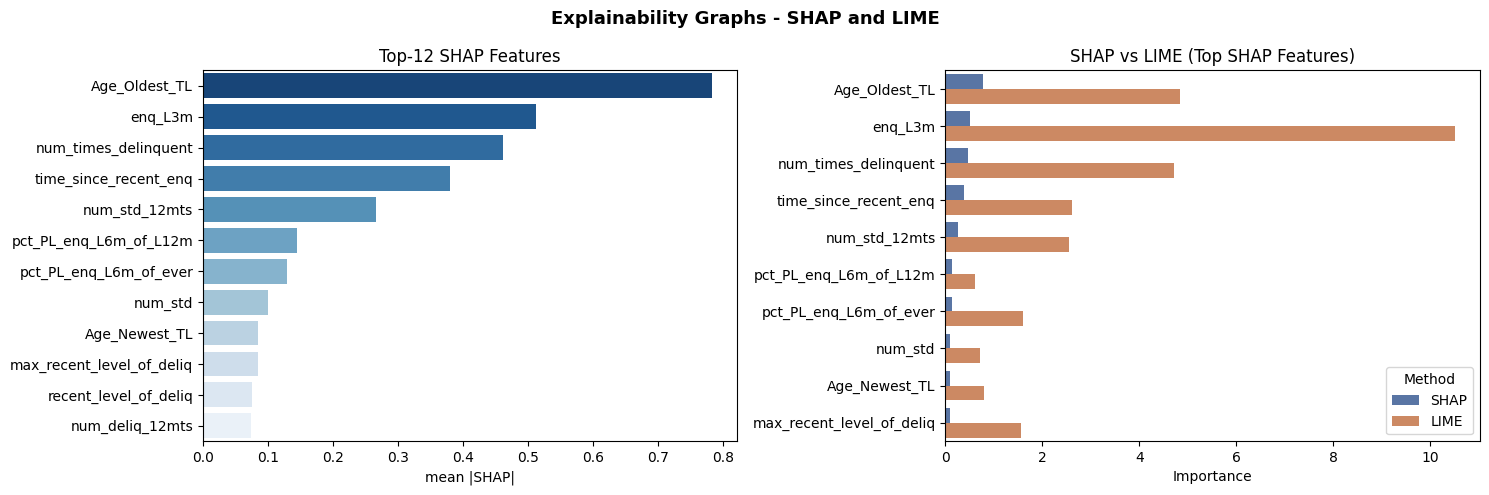

In [43]:
# Comparison graph similar to the older notebook style.
comp_feats = shap_rank.head(10).index
comp_df = pd.DataFrame({
    "SHAP": shap_rank.loc[comp_feats],
    "LIME": lime_rank.reindex(comp_feats).fillna(0.0),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=shap_rank.head(12).values, y=shap_rank.head(12).index, palette="Blues_r", ax=axes[0])
axes[0].set_title("Top-12 SHAP Features")
axes[0].set_xlabel("mean |SHAP|")
axes[0].set_ylabel("")

comp_melt = comp_df.reset_index().melt(id_vars="index", var_name="Method", value_name="Importance")
sns.barplot(data=comp_melt, x="Importance", y="index", hue="Method", palette=["#4C72B0", "#DD8452"], ax=axes[1])
axes[1].set_title("SHAP vs LIME (Top SHAP Features)")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

plt.suptitle("Explainability Graphs - SHAP and LIME", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [44]:
top_k = 30
common_feats = shap_rank.head(top_k).index.intersection(lime_rank.head(top_k).index)

if len(common_feats) >= 5:
    shap_pos = pd.Series(range(1, len(shap_rank) + 1), index=shap_rank.index)
    lime_pos = pd.Series(range(1, len(lime_rank) + 1), index=lime_rank.index)
    tau, p_val = kendalltau(shap_pos.loc[common_feats].values, lime_pos.loc[common_feats].values)
else:
    tau, p_val = np.nan, np.nan

explainability_results = pd.DataFrame([
    {"Metric": "SHAP sample size", "Value": int(SHAP_N)},
    {"Metric": "LIME sample size", "Value": int(LIME_N)},
    {"Metric": "Common top-feature count", "Value": int(len(common_feats))},
    {"Metric": "Kendall tau (LIME vs SHAP)", "Value": None if pd.isna(tau) else round(float(tau), 4)},
    {"Metric": "Kendall p-value", "Value": None if pd.isna(p_val) else round(float(p_val), 6)},
])

print("Explainability Consistency")
display(explainability_results)

Explainability Consistency


,Metric,Value
0,SHAP sample size,500.0000
1,LIME sample size,120.0000
2,Common top-feature count,25.0000
3,Kendall tau (LIME vs SHAP),0.6733
4,Kendall p-value,0.0000


## Fairness Audit (DPD, EOD, DIR)

In [45]:
accepted_grades = {"P1", "P2"}
y_true_label = label_encoder.inverse_transform(y_test)
y_pred_label = label_encoder.inverse_transform(y_pred_hybrid)

y_true_bin = np.array([1 if g in accepted_grades else 0 for g in y_true_label])
y_pred_bin = np.array([1 if g in accepted_grades else 0 for g in y_pred_label])

def find_col_like(df_in: pd.DataFrame, candidates):
    low_map = {c.lower(): c for c in df_in.columns}
    for cand in candidates:
        for low, orig in low_map.items():
            if cand in low:
                return orig
    return None

gender_col = find_col_like(df_test_raw, ["gender"])
marital_col = find_col_like(df_test_raw, ["marital"])
age_col = find_col_like(df_test_raw, ["age"])

In [46]:
sensitive_groups = {}
if gender_col is not None:
    sensitive_groups["Gender"] = df_test_raw[gender_col].astype(str)
if marital_col is not None:
    sensitive_groups["Marital Status"] = df_test_raw[marital_col].astype(str)
if age_col is not None:
    age_series = pd.to_numeric(df_test_raw[age_col], errors="coerce")
    sensitive_groups["Age"] = np.where(age_series < 30, "Under 30", "30 and above")

In [47]:
fair_rows = []
for name, sf in sensitive_groups.items():
    dpd = demographic_parity_difference(y_true=y_true_bin, y_pred=y_pred_bin, sensitive_features=sf)
    eod = equalized_odds_difference(y_true=y_true_bin, y_pred=y_pred_bin, sensitive_features=sf)

    mf = MetricFrame(metrics=selection_rate, y_true=y_true_bin, y_pred=y_pred_bin, sensitive_features=sf)
    by_group = mf.by_group
    min_sr = float(by_group.min()) if len(by_group) else np.nan
    max_sr = float(by_group.max()) if len(by_group) else np.nan
    dir_ratio = (min_sr / max_sr) if (max_sr > 0) else np.nan

    fair_rows.append({
        "Sensitive Attribute": name,
        "DPD": round(float(dpd), 4),
        "EOD": round(float(eod), 4),
        "DIR": round(float(dir_ratio), 4) if not pd.isna(dir_ratio) else np.nan,
    })

In [48]:
fairness_results = pd.DataFrame(fair_rows)

print("Fairness Audit")
display(fairness_results)

Fairness Audit


,Sensitive Attribute,DPD,EOD,DIR
0,Gender,0.0072,0.0517,0.9906
1,Marital Status,0.1291,0.0950,0.8362
2,Age,0.2110,0.1937,0.7521


## Gemini Explanation Layer (Preserved)

In [50]:
import re
import time

load_dotenv(project_root / ".env")
gemini_key = (
    os.getenv("GEMINI_API_KEY")
    or os.getenv("GOOGLE_API_KEY")
    or os.getenv("GOOGLE_GENAI_API_KEY")
)
if not gemini_key:
    raise ValueError("Gemini API key not found. Set GEMINI_API_KEY (or GOOGLE_API_KEY) in .env")

# Try multiple model aliases because availability can differ by account/region.
MODEL_CANDIDATES = [
    "gemini-2.5-flash",
    "gemini-2.5-flash-lite",
    "gemini-2.0-flash",
    "gemini-2.0-flash-lite",
    "gemini-1.5-flash",
]

def _make_llm(model_name: str):
    return ChatGoogleGenerativeAI(
        model=model_name,
        google_api_key=gemini_key,
        temperature=0.2,
        max_retries=3,
    )

def _invoke_with_backoff(llm_obj, messages, retries: int = 2):
    last_err = None
    for attempt in range(retries + 1):
        try:
            return llm_obj.invoke(messages)
        except Exception as err:
            last_err = err
            err_msg = str(err)
            is_quota = ("RESOURCE_EXHAUSTED" in err_msg) or ("429" in err_msg)
            if (not is_quota) or (attempt == retries):
                raise

            wait_s = 45
            m = re.search(r"retry in\s*([0-9]+(?:\.[0-9]+)?)s", err_msg, flags=re.IGNORECASE)
            if m:
                wait_s = max(wait_s, int(float(m.group(1))) + 2)

            print(f"Gemini quota hit (attempt {attempt + 1}/{retries + 1}). Waiting {wait_s}s...")
            time.sleep(wait_s)

    raise RuntimeError(f"Gemini invocation failed after retries: {last_err}")

def _invoke_with_model_fallback(messages, retries_per_model: int = 1):
    errors = []
    for model_name in MODEL_CANDIDATES:
        try:
            llm_obj = _make_llm(model_name)
            resp = _invoke_with_backoff(llm_obj, messages, retries=retries_per_model)
            return resp, model_name
        except Exception as err:
            errors.append(f"{model_name}: {str(err)[:160]}")
            continue

    raise RuntimeError(
        "Could not get Gemini response from any candidate model. "
        + " | ".join(errors)
    )

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a credit analyst assistant explaining outcomes to bank staff."),
    ("human", "Evidence JSON:\n{evidence_json}\n\nRespond in short structured form with Decision, Grade, Confidence, Reason, Risk note."),
])

N_EXPLAIN = min(5, len(X_test_tree))
explanations = []
model_usage = []

for idx in X_test_tree.index[:N_EXPLAIN].tolist():
    loc = X_test_tree.index.get_loc(idx)
    probs = hybrid_probs[loc]
    pred_idx = int(np.argmax(probs))
    grade = label_encoder.inverse_transform([pred_idx])[0]
    decision = "Accepted" if grade in accepted_grades else "Rejected"

    evidence = {
        "grade": grade,
        "decision": decision,
        "confidence_pct": f"{float(np.max(probs))*100:.1f}%",
        "class_probs": {cls: f"{float(probs[i])*100:.1f}%" for i, cls in enumerate(classes)},
        "top_drivers": shap_rank.head(3).index.tolist(),
    }

    response, model_name = _invoke_with_model_fallback(
        prompt.format_messages(evidence_json=json.dumps(evidence, indent=2)),
        retries_per_model=2,
    )

    model_usage.append(model_name)
    text = response.content.strip()
    explanations.append({
        "row_index": int(idx),
        "decision": decision,
        "grade": grade,
        "explanation": text,
    })

    print(f"Case {idx} ({decision}/{grade}) | model: {model_name}")
    print(text)
    print("-" * 60)

print("Models used:", sorted(set(model_usage)))

Case 41161 (Accepted/P2) | model: gemini-2.5-flash
**Decision:** Accepted
**Grade:** P2
**Confidence:** 89.6%
**Reason:** The primary factors influencing this decision are the age of the oldest trade line, recent inquiries (last 3 months), and the number of times delinquent.
**Risk note:** P2 indicates a good credit profile with a low to moderate risk of default.
------------------------------------------------------------
Case 1164 (Accepted/P1) | model: gemini-2.5-flash
**Decision:** Accepted
**Grade:** P1
**Confidence:** 86.4%
**Reason:** The application was accepted with a P1 grade primarily due to a strong credit profile, indicated by factors such as the age of the oldest trade line, low recent inquiries (enq_L3m), and a favorable history regarding the number of times delinquent.
**Risk note:** While confidence in the P1 grade is high, there is a small probability (9.0% for P2, 4.0% for P3) of a slightly higher risk profile. Continued monitoring of recent credit inquiries and deli

## Save Artifacts

In [51]:
artifacts_dir = project_root / "model" / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "label_encoder": label_encoder,
    "feature_columns": X.columns.tolist(),
    "categorical_cols": categorical_cols,
    "scaler_nn": scaler_nn,
    "calibrated_ensemble": calibrated_ensemble,
    "blend_weights": {"ensemble": W_ENS, "nn": W_NN},
}

with open(artifacts_dir / "hybrid_bundle.pkl", "wb") as f:
    pickle.dump(bundle, f)

torch.save(nn_model.state_dict(), artifacts_dir / "nn_state_dict.pt")

metadata = {
    "classes": classes.tolist(),
    "n_features": int(X.shape[1]),
    "nn_epochs": EPOCHS,
    "p3_multiplier": 1.35,
    "stack_models": ["RandomForest", "XGBoost", "HistGradientBoosting"],
    "blend_weights": {"ensemble": W_ENS, "nn": W_NN},
    "cv_f1_weighted": float(cv_results["test_f1_weighted"].mean()),
    "cv_roc_auc_ovr_weighted": float(cv_results["test_roc_auc_ovr_weighted"].mean()),
    "ablation_results": ablation_results.to_dict(orient="records") if "ablation_results" in globals() else [],
    "fairness_results": fairness_results.to_dict(orient="records") if "fairness_results" in globals() else [],
    "explainability_results": explainability_results.to_dict(orient="records") if "explainability_results" in globals() else [],
}

with open(artifacts_dir / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

if len(explanations) > 0:
    report_path = artifacts_dir / "llm_decision_explanations.md"
    lines = [
        "# Credit Decision Explanations",
        f"Blend: Ensemble {W_ENS:.0%} + NN {W_NN:.0%}",
        "",
    ]
    for item in explanations:
        lines += [
            f"## Case {item['row_index']} - {item['decision']} ({item['grade']})",
            item["explanation"],
            "",
        ]
    report_path.write_text("\n".join(lines), encoding="utf-8")

print("Artifacts saved at:", artifacts_dir)

Artifacts saved at: c:\Users\KIIT0001\Desktop\Projects\Credit Scoring\model\artifacts
